In [23]:
from samap.mapping import SAMAP
from samap.analysis import (get_mapping_scores, GenePairFinder, transfer_annotations,
                            sankey_plot, chord_plot, CellTypeTriangles, 
                            ParalogSubstitutions, FunctionalEnrichment,
                            convert_eggnog_to_homologs, GeneTriangles)
from samalg import SAM
import pandas as pd
from Bio import SeqIO
from samap.utils import (save_samap, load_samap)
import scanpy as sc
import matplotlib.colors
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
from scipy import sparse 
from scipy import cluster
import seaborn as sns
import random
import sklearn
from scipy.stats import poisson
from sklearn.neighbors import KernelDensity
import time
import dill
from scipy.optimize import minimize
import pickle
import itertools
import os
import time
import scipy.sparse as sp

In [ ]:
#cluster to eq supertype mapping
#Oxt = ['2379 PVH-SO-PVa Otp Glut_4', '2381 PVH-SO-PVa Otp Glut_4']
#Avp = ['2380 PVH-SO-PVa Otp Glut_4']
#Ucn3 = ['2386 PVH-SO-PVa Otp Glut_6', '2385 PVH-SO-PVa Otp Glut_6']
#Trh = ['2375 PVH-SO-PVa Otp Glut_3']
#Crh = ['2378 PVH-SO-PVa Otp Glut_3', '2376 PVH-SO-PVa Otp Glut_3', '2377 PVH-SO-PVa Otp Glut_3']
#Sst = ['2382 PVH-SO-PVa Otp Glut_5', '2383 PVH-SO-PVa Otp Glut_5', '2384 PVH-SO-PVa Otp Glut_5']
#Nkx2-2 = ['2365 PVH-SO-PVa Otp Glut_1', '2374 PVH-SO-PVa Otp Glut_2', '2369 PVH-SO-PVa Otp Glut_2', '2373 PVH-SO-PVa Otp Glut_2', '2371 PVH-SO-PVa Otp Glut_2', '2366 PVH-SO-PVa Otp Glut_1', '2364 PVH-SO-PVa Otp Glut_1', '2370 PVH-SO-PVa Otp Glut_2', '2368 PVH-SO-PVa Otp Glut_1', '2372 PVH-SO-PVa Otp Glut_2', '2367 PVH-SO-PVa Otp Glut_1']

In [24]:
Allen_labs = pd.read_csv('../../Subclustering/PVH/Allen_labels_PVH_withcluster_09092026.csv',index_col='Unnamed: 0')

In [118]:
fn = '../../Subclustering/PVH/SAM_DR_cleaned_PVH_09082026.h5ad'

sam = SAM()
sam.load_data(fn)

In [119]:
sam_test = SAM()
sam_test.load_data('../../Active_SAM_joined/SAM_DR_ncbi_joined_cleaned_07172026.h5ad')

In [120]:
sam_test.adata.obs.columns

Index(['n_genes', 'n_counts', 'key', 'leiden_clusters_neuron', 'eq_subclass',
       'eq_subclass_lc', 'leiden_clusters', 'eq_subclass_nounlabeled',
       'ss_subclass', 'ss_subclass_v4_nounlabeled',
       'ss_subclass_v4_nounlabeled_nn', 'ss_subclass_nounlabeled_nmm_v4_nn',
       'ss_subclass_nounlabeled_nmm_v4_nn_thresh30',
       'ss_subclass_nounlabeled_nmm_cl_v4_nn', 'neurotransmitter_v3',
       'yanay_labels', 'yanay_label_nounlabeled', 'ss_subclass_old',
       'ss_subclass_v5_nounlabeled', 'ss_subclass_v5_nounlabeled_nn',
       'ss_subclass_nounlabeled_nmm_v5_nn',
       'ss_subclass_nounlabeled_nmm_cl_v5_nn'],
      dtype='object')

In [121]:
tester = sam_test.adata[sam_test.adata.obs['ss_subclass'] == '133 PVH-SO-PVa Otp Glut']

In [122]:
tester.X

<428x25503 sparse matrix of type '<class 'numpy.float32'>'
	with 149055 stored elements in Compressed Sparse Row format>

In [123]:
sam.adata.X

<428x25503 sparse matrix of type '<class 'numpy.float32'>'
	with 149055 stored elements in Compressed Sparse Row format>

In [124]:
def csr_equal(A, B):
    if A.shape != B.shape:
        return False
    return (A != B).nnz == 0

In [125]:
csr_equal(tester.X,sam.adata.X)

True

In [126]:
sam.clustering(param = 2)

In [127]:
org_two = 'dr'

In [128]:
fn_sm = '../../Subclustering/PVH/sm_mg_'+org_two+'_PVH_09082026.pkl'
sm = load_samap(fn_sm)

In [129]:
sm.sams['mg'].adata.obs['eq_supertype'] = Allen_labs['eq_supertype']

In [130]:
sm.sams['mg'].adata.obs.columns

Index(['Unnamed: 0', 'cell_label', 'cell_barcode',
       'barcoded_cell_sample_label', 'library_label', 'feature_matrix_label',
       'entity', 'brain_section_label', 'library_method',
       'region_of_interest_acronym', 'donor_label', 'donor_genotype',
       'donor_sex', 'dataset_label', 'x', 'y', 'cluster_alias',
       'subclass_id_label', 'supertype_id_label', 'class_id_label',
       'leiden_clusters', 'eq_supertype'],
      dtype='object')

In [131]:
csr_equal(sm.sams[org_two].adata.X,sam.adata.X)

True

In [132]:
sm.sams[org_two].clustering(param = 2)

In [133]:
keys = {'mg':'eq_supertype',org_two:'leiden_clusters'}
D,MappingTable = get_mapping_scores(sm,keys)

lim_MappingTable = MappingTable.filter(like='mg_')
lim_MappingTable = lim_MappingTable[lim_MappingTable.index.str.contains(org_two + '_')]

In [134]:
lim_MappingTable.to_csv('../../Subclustering/PVH/mg_'+org_two+'_mapping_PVH_test_09082026.csv')

In [135]:
org_thresh = {'mo':0.2,'cj':0.2,'ac':0.2,'xt':0.2,'dr':0.15}

In [136]:
fin_mapping = {}
for item in lim_MappingTable.index:
    bm = lim_MappingTable.loc[item,:].idxmax()
    if lim_MappingTable.loc[item,bm] > org_thresh[org_two]:
        fin_mapping[item] = bm
    else:
        fin_mapping[item] = item
        
fin_labels = []
for item in sam.adata.obs['leiden_clusters']:
    fin_labels.append(fin_mapping[org_two + '_' + str(item)][3:])

In [137]:
sam.adata.obs['test'] = fin_labels

In [21]:
mg_genes = ['Avp','Oxt','Nkx2-2','Ucn3','Sst','Crh','Ucn','Trh',]
mo_genes = ['Avp','Oxt','Nkx2-2','UCN3','Sst','Crh','UCN','Trh',]
cj_genes = ['ENSCJPG00005007573','ENSCJPG00005007570','ENSCJPG00005006711','SST','CRH','UCN','TRH']
ac_genes = ['LOC134299523','LOC134299526','nkx2-2','ucn3','sst','crh','trh']
xt_genes = ['avp','oxt','nkx2-2','ucn3','sst.1','ENSXETG00000035344','UCN','trh']
dr_genes = ['avp','oxt','nkx2.2a','ucn3l','sst1.1','crhb','uts1','trh']

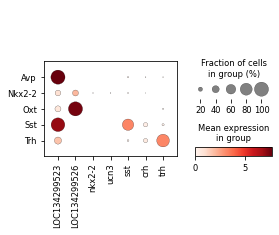

In [22]:
sc.pl.dotplot(sam.adata, groupby = 'test', var_names =ac_genes)

In [23]:
fin_mapping

{'ac_0': 'mg_Nkx2-2',
 'ac_1': 'mg_Avp',
 'ac_10': 'mg_Sst',
 'ac_2': 'mg_Nkx2-2',
 'ac_3': 'mg_Oxt',
 'ac_4': 'mg_Sst',
 'ac_5': 'mg_Avp',
 'ac_6': 'mg_Nkx2-2',
 'ac_7': 'mg_Nkx2-2',
 'ac_8': 'mg_Trh',
 'ac_9': 'ac_9'}

In [138]:
sam.adata.obs['test'] = sam.adata.obs['test'].astype('category')

In [139]:
sam.adata.obs['test'].equals(sam.adata.obs['eq_supertype'])

True

In [24]:
fin_labels = []
for item in sam.adata.obs['leiden_clusters']:
    fin_labels.append(fin_mapping[org_two + '_' + str(item)][3:])

In [26]:
sam.adata.obs['eq_supertype'] = fin_labels
sm.sams[org_two].adata.obs['eq_supertype'] = fin_labels

In [27]:
sm.sams[org_two].adata.obs['org_clusters'] = sam.adata.obs['leiden_clusters']
sam.adata.obs['org_clusters'] = sam.adata.obs['leiden_clusters']

In [28]:
sam.adata.obs['eq_supertype']

AGGCCACGTGCAACTT      Nkx2-2
AGGTCATTCCGATATG         Avp
CGTAGGCAGACTGTAA         Sst
GACGTGCCAGCGTAAG         Avp
GCGACCATCCCAGGTG         Sst
                       ...  
TGATTTCCAAGAGGCT         Sst
TGCACCTCATAAGACA         Crh
TGGTTAGTCGCCTGAG-1       Avp
TTATGCTGTTCCGGCA         Avp
TTCGAAGGTCTCTTAT         Sst
Name: eq_supertype, Length: 428, dtype: object

In [29]:
sam.save_anndata(fn)

In [30]:
save_samap(sm,fn_sm)